### Configuração do LDA

In [2]:
import pandas as pd
import gensim
from gensim import corpora
from gensim.models import LdaModel
import nltk
import re

In [128]:
# Carrega o dataset
df_novo = pd.read_csv('./datasets/database-lemmetizado.csv.zip', compression='zip')
df_novo = df_novo.sort_values('date_published').reset_index(drop=True)

In [ ]:
documents = df_novo['tokens'].dropna().astype(str).tolist()

In [22]:
# Usar esse caso o dataset esteja pre-processado
def tokenize_text(text):
    """
    Função para tokenizar o texto.
    """

    # Converte para minúsculas e separa em palavras
    tokens = text.lower().split()

    return tokens

# Tokeniza os textos
processed_docs = [tokenize_text(doc) for doc in documents]

# Cria dicionário e corpus
# O dicionário mapeia cada palavra a um ID único.
dictionary = corpora.Dictionary(processed_docs)

# O corpus é a representação Bag-of-Words de cada documento.
# Para cada documento, ele contém uma lista de tuplas (ID_da_palavra, frequência).
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

In [23]:
print(f"Número de documentos: {len(corpus)}")
print(f"Tamanho do dicionário: {len(dictionary)}")
print(f"Exemplo de documento (Bag-of-Words): {corpus[0]}")
print(f"processed_docs[0]: {processed_docs[0]}")

Número de documentos: 25240
Tamanho do dicionário: 48753
Exemplo de documento (Bag-of-Words): [(0, 1), (1, 1), (2, 1), (3, 4), (4, 2), (5, 2), (6, 1), (7, 4), (8, 1), (9, 3), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 3), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 1), (28, 1), (29, 1), (30, 1), (31, 1), (32, 1), (33, 1), (34, 4), (35, 1), (36, 1)]
processed_docs[0]: ["['dispositivo',", "'eletrocrèmico',", "'combinação',", "'eletrocrèmica',", "'patente',", "'invenção',", "'dispositivo',", "'eletrocrèmico',", "'combinação',", "'eletrocrèmico',", "'apresentar',", "'dispositivo',", "'eletrocrómico',", "'aplicação',", "'superfície',", "'dispositivo',", "'utilizar',", "'camada',", "'regulação',", "'óptico',", "'modo',", "'reduzir',", "'pequeno',", "'interferência',", "'óptico',", "'camada',", "'estrutura',", "'modo',", "'aumentar',", "'transparência',", "'óptico',", "'uniforme',", "'sintonização',", "'óptico',", "'permitir',

### Treinamento do modelo

In [ ]:
# Treina o modelo LDA
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10, # Número de tópicos
    random_state=42,
    passes=20,
    alpha='auto', # (Document-Topic Density): Controla a mistura de tópicos por documento
    eta='auto' # (Topic-Word Density): Controla a mistura de palavras por tópico
)

In [ ]:
from gensim.models import LdaSeqModel

# 1. Converter a coluna de datas para datetime
df_novo['date_published'] = pd.to_datetime(df_novo['date_published'], errors='coerce')

# 2. Definir as faixas de 4 anos
start_year = df_novo['date_published'].dt.year.min()
end_year = df_novo['date_published'].dt.year.max()
bins = list(range(start_year, end_year + 5, 4))
period_labels = [f"{y}-{y+3}" for y in bins[:-1]]

print(period_labels)

# 3. Criar coluna de faixa temporal
df_novo['period'] = pd.cut(df_novo['date_published'].dt.year, bins=bins, labels=period_labels, right=False)

['1999-2002', '2003-2006', '2007-2010', '2011-2014', '2015-2018', '2019-2022', '2023-2026']
[1999, 2003, 2007, 2011, 2015, 2019, 2023, 2027]


In [ ]:
# 4. Treinar o modelo DTM (LdaSeqModel)
ldaseq = LdaSeqModel(
	corpus=corpus,
	time_slice=df_novo['period'].value_counts().sort_index().to_list(),
	id2word=dictionary,
	initialize='gensim',
	num_topics=10
)

print("Modelo DTM treinado com sucesso!")

In [127]:
ldaseq.save("./modelos/dtm_model")

In [57]:
# Exibe os tópicos encontrados
for idx, topic in enumerate(ldaseq.print_topics()):

    print(f'Tópico {idx}: {topic}')

    

Tópico 0: [("'controle',", 0.01958593855247271), ("'dispositivo',", 0.01858886484058117), ("'máquina',", 0.017207919523405606), ("'aparelho',", 0.015880097589856708), ("'unidade',", 0.015186808778435467), ("'método',", 0.01393861783611014), ("'elétrico',", 0.013104067889537068), ("'energia',", 0.01027336872693694), ("'hidráulico',", 0.00970418513116426), ("'invenção',", 0.008477926835199653), ("'motor',", 0.008385478627256599), ("'incluir',", 0.007988031018922651), ("'operação',", 0.007675671659080033), ("'compreender',", 0.007200106575378134), ("'sinal',", 0.007150263261426815), ("'veículo',", 0.007016250652221077), ("'controlar',", 0.006639953617837922), ("'fluido',", 0.006625620938433615), ("'bomba',", 0.00639576655908076), ("'pressão',", 0.005495177032935086)]
Tópico 1: [("'janela',", 0.06656030843853318), ("'porta',", 0.059965304683575624), ("'perfil',", 0.038620447356811034), ("'vidro',", 0.037302701356675745), ("'folha',", 0.024960444786682814), ("'b',", 0.024764736173758805), (

### Gráfico de Tópicos

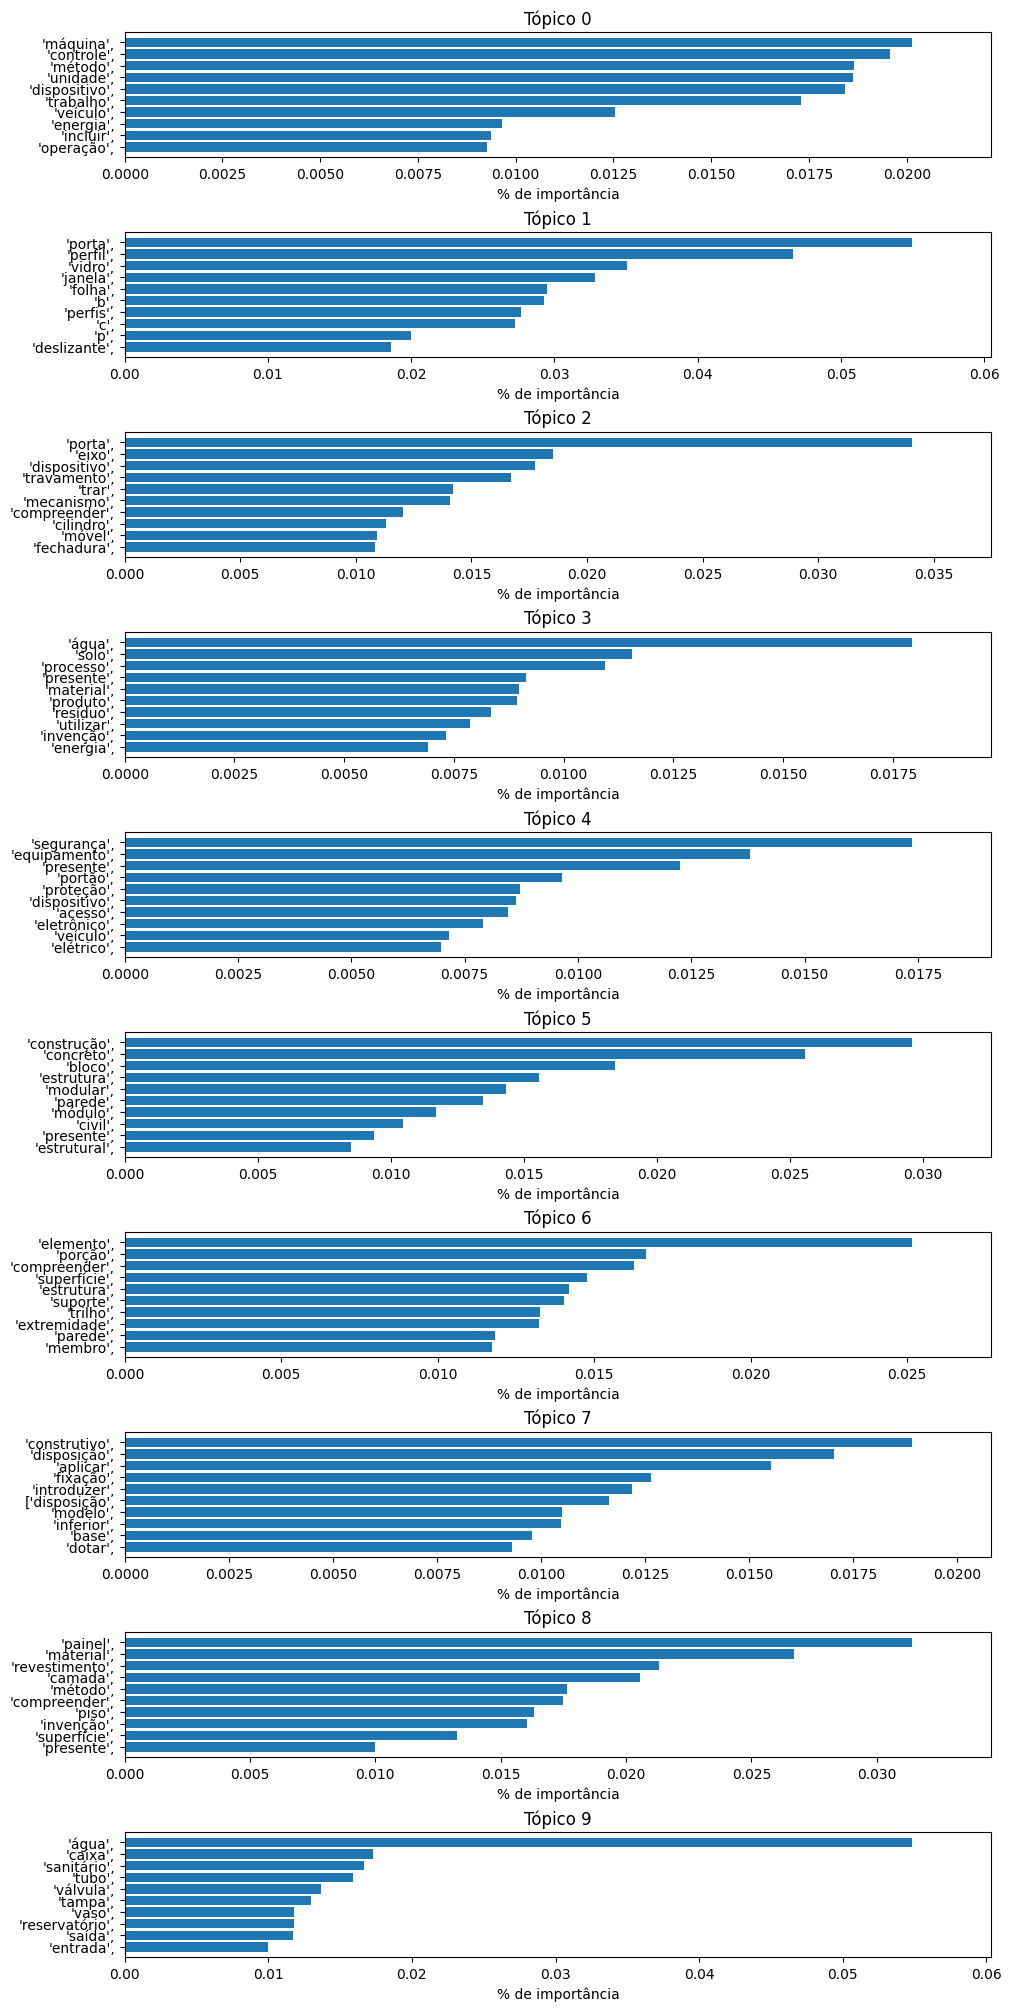

Gráfico salvo como 'lda_topicos.png'


In [ ]:
import matplotlib.pyplot as plt

# Extrai os tópicos e palavras (no primeiro time slice)
topics = ldaseq.print_topics(top_terms=10, time=6)

fig, axes = plt.subplots(len(topics), 1, figsize=(10, 2 * len(topics)), constrained_layout=True)

for topic_idx, terms in enumerate(topics):
    words = [w for w, p in terms]
    probs = [p for w, p in terms]
    axes[topic_idx].barh(words, probs)
    axes[topic_idx].set_title(f'Tópico {topic_idx}')
    axes[topic_idx].invert_yaxis()
    axes[topic_idx].set_xlabel('% de importância')
    axes[topic_idx].set_xlim(0, max(probs)*1.1)

fig.savefig('./graficos/lda_topicos.png', dpi=300)
plt.show()
plt.close(fig)

### Data Frame com os tópicos de cada patente

In [58]:
# 1. Definir os nomes dos tópicos conforme sua interpretação.
topic_names = {
    0: 'Controle de máquinas e sistemas de energia',
    1: 'Esquadrias e sistemas de vedação',
    2: 'Fechaduras e mecanismos de travamento',
    3: 'Água, solo e tratamento ambiental',
    4: 'Segurança e acesso',
    5: 'Construção civil e elementos estruturais',
    6: 'Componentes estruturais e de fixação',
    7: 'Soluções construtivas e montagem mecânica',
    8: 'Materiais de revestimento e isolamento',
    9: 'Sistemas hidráulicos sanitários'
}

In [79]:
import pandas as pd

# 2. Preparar uma lista para armazenar os dados de cada patente.
corpus_topics_data = []

# 3. Iterar sobre cada documento no seu corpus.
for i, doc_bow in enumerate(corpus):
    # Pega a distribuição de tópicos para o documento atual.
    forward_citations = df_novo["patent_count"].iloc[i]
    if forward_citations == 0:
        continue

    doc_topics = ldaseq.doc_topics(i)
        
    # Adiciona o ID e titulo da patente à informação.
    # Assumindo que 'lista_patentes' tem os títulos ou IDs.
    topic_probabilities = {}
    for topic_num, prob_topic in enumerate(doc_topics):
        topic_probabilities[topic_names[topic_num]] = prob_topic
    topic_probabilities['ID'] = df_novo["docdb_id"].iloc[i]
    topic_probabilities['Nome'] = df_novo["invention_title_text"].iloc[i]
    topic_probabilities['Forward Citations'] = forward_citations
    topic_probabilities['Período'] = df_novo["period"].iloc[i]
    
    # Adiciona o dicionário completo à nossa lista de dados.
    corpus_topics_data.append(topic_probabilities)

# 4. Criar o DataFrame do pandas.
df_topics = pd.DataFrame(corpus_topics_data)

# 5. Criar uma coluna para identificar o tópico dominante de cada patente.
# O método idxmax() encontra o nome da coluna (nosso nome de tópico) com o maior valor na linha.
df_topics['Tópico Principal'] = df_topics[list(topic_names.values())].idxmax(axis=1)

# 6. Ordena os campos para melhor visualização.
df_topics = df_topics[['ID', 'Nome', 'Tópico Principal', 'Forward Citations', 'Período'] + list(topic_names.values())]

In [80]:
df_topics

,ID,Nome,Tópico Principal,Forward Citations,Período,Controle de máquinas e sistemas de energia,Esquadrias e sistemas de vedação,Fechaduras e mecanismos de travamento,"Água, solo e tratamento ambiental",Segurança e acesso,Construção civil e elementos estruturais,Componentes estruturais e de fixação,Soluções construtivas e montagem mecânica,Materiais de revestimento e isolamento,Sistemas hidráulicos sanitários
0,383303056,Disposição construtiva introduzida em reservat...,Soluções construtivas e montagem mecânica,1,1999-2002,0.000151,0.000151,0.000151,0.000151,0.000151,0.261335,0.009679,0.549581,0.000151,0.178498
1,295401940,"Estrutura de parede laminada, isolamento exter...",Materiais de revestimento e isolamento,1,1999-2002,0.000158,0.000158,0.000158,0.000158,0.000158,0.205331,0.000158,0.000158,0.754976,0.038584
2,383304521,disposições construtivas introduzidas em torre...,Soluções construtivas e montagem mecânica,3,1999-2002,0.000143,0.000143,0.000143,0.000143,0.074192,0.173603,0.104666,0.646683,0.000143,0.000143
3,297761449,"Processo de construção de coluna (s), parede (...",Construção civil e elementos estruturais,1,1999-2002,0.000063,0.031730,0.013125,0.000063,0.000063,0.581411,0.207415,0.000063,0.166003,0.000063
4,296632552,Capa de estaca.,Componentes estruturais e de fixação,3,1999-2002,0.000181,0.052088,0.000181,0.136326,0.000181,0.000181,0.634823,0.164859,0.000181,0.010996
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,580237262,SISTEMA DE PROTEÇÃO INDIVIDUAL ATRAVÉS DE DISP...,Segurança e acesso,1,2019-2022,0.000109,0.073789,0.000109,0.000109,0.489700,0.183234,0.128466,0.124269,0.000109,0.000109
914,581109150,MEMBRO DE DESGASTE PARA EQUIPAMENTO DE TRABALH...,Componentes estruturais e de fixação,1,2019-2022,0.168555,0.000178,0.047551,0.096419,0.000178,0.000178,0.686406,0.000178,0.000178,0.000178
915,586397894,SISTEMA DE ACIONAMENTO ROTATIVO AUTORRETRÁTIL ...,Fechaduras e mecanismos de travamento,1,2023-2026,0.000154,0.213671,0.456802,0.000154,0.032830,0.000154,0.000154,0.295776,0.000154,0.000154
916,587065428,SISTEMA INTEGRADO DE GERENCIAMENTO E MONITORAM...,Controle de máquinas e sistemas de energia,1,2023-2026,0.439117,0.000158,0.000158,0.422138,0.051424,0.086370,0.000158,0.000158,0.000158,0.000158


### Cálculo da Emergência dos Tópicos

In [112]:
# multiply every topic column by Forward Citations
weighted = df_topics[topic_names.values()].mul(df_topics["Forward Citations"], axis=0)

# group by period and sum
topic_emergence_scores = (
    weighted.groupby(df_topics["Período"])
            .sum()
            .reindex(period_labels)  # keep desired order/index
)

topic_emergence_scores

,Controle de máquinas e sistemas de energia,Esquadrias e sistemas de vedação,Fechaduras e mecanismos de travamento,"Água, solo e tratamento ambiental",Segurança e acesso,Construção civil e elementos estruturais,Componentes estruturais e de fixação,Soluções construtivas e montagem mecânica,Materiais de revestimento e isolamento,Sistemas hidráulicos sanitários
Período,,,,,,,,,,
1999-2002,3.254798,1.658242,3.632231,5.301106,7.630477,10.468217,10.052854,10.755424,3.878979,10.367672
2003-2006,7.668692,3.846651,7.663339,13.618168,12.648162,23.348856,11.564298,28.618866,10.439933,14.583035
2007-2010,16.954751,9.614975,21.254245,21.981353,33.187631,55.616620,20.868456,59.258809,10.638136,36.625022
2011-2014,18.424683,16.389113,19.900003,30.714133,46.676340,51.082465,26.126957,61.466384,17.229551,35.990370
2015-2018,28.324736,13.607511,29.412086,26.953129,74.485735,48.378308,40.251257,99.350237,24.728244,30.508758
2019-2022,9.517425,7.820451,14.896566,10.899597,12.798132,16.132778,14.761305,26.391801,7.780996,11.000949
2023-2026,0.537192,0.213943,0.457074,0.574675,0.084368,0.835424,0.000426,0.296048,0.000426,0.000426


## Visualizar uma patente especifica

C:\Users\luish\AppData\Local\Temp\ipykernel_19496\3269435232.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=probabilidades_topicos.index, y=probabilidades_topicos.values, palette='viridis')


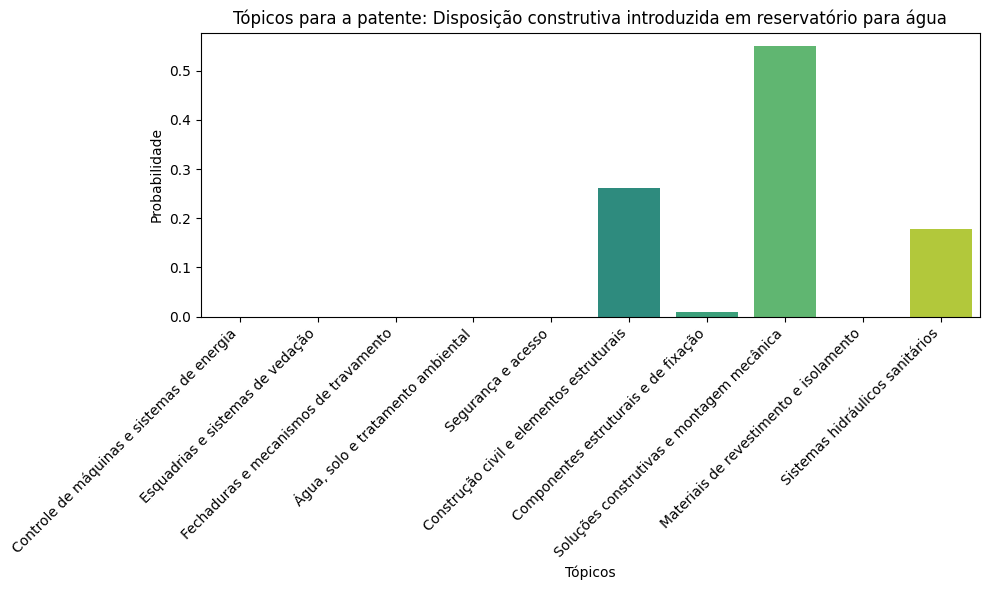

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

indice_patente = 0
patente_especifica = df_topics.iloc[indice_patente]

# Pega apenas as colunas que representam as probabilidades dos tópicos
probabilidades_topicos = patente_especifica[list(topic_names.values())]

# Cria o gráfico
plt.figure(figsize=(10, 6)) # Define o tamanho da figura
sns.barplot(x=probabilidades_topicos.index, y=probabilidades_topicos.values, palette='viridis')

# Adiciona títulos e rótulos
plt.title(f'Tópicos para a patente: {patente_especifica["Nome"]}')
plt.xlabel('Tópicos')
plt.ylabel('Probabilidade')
plt.xticks(rotation=45, ha='right') # Rotaciona os nomes dos tópicos para não sobrepor
plt.tight_layout() # Ajusta o layout para caber tudo

# Mostra o gráfico
plt.show()

### Gráfico de Emergência dos Tópicos por Período

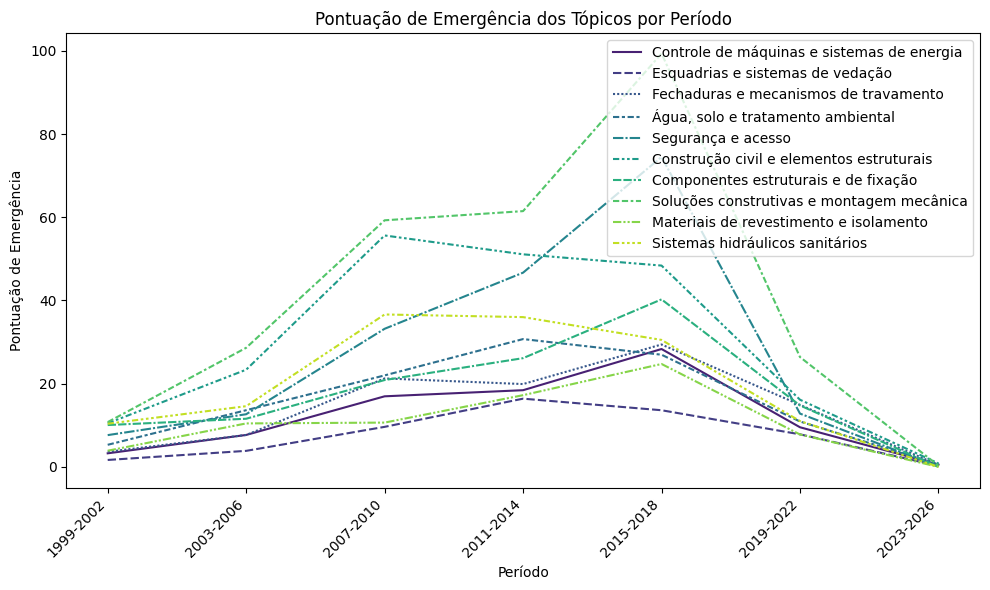

In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pega apenas as colunas que representam as probabilidades dos tópicos
probabilidades_topicos = patente_especifica[list(topic_names.values())]

# Cria o gráfico
plt.figure(figsize=(10, 6)) # Define o tamanho da figura
sns.lineplot(data=topic_emergence_scores, palette='viridis')

# Adiciona títulos e rótulos
plt.title(f'Pontuação de Emergência dos Tópicos por Período')
plt.xlabel('Período')
plt.ylabel('Pontuação de Emergência')
plt.xticks(rotation=45, ha='right') # Rotaciona os nomes dos tópicos para não sobrepor
plt.tight_layout() # Ajusta o layout para caber tudo

# Mostra o gráfico
plt.savefig('./graficos/emergencia_topicos_periodo.png', dpi=300)
plt.show()
plt.close()